In [49]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#splitting the dataset 
df=pd.read_csv('./dataset/train.csv')
df.fillna(0)

selected_features = [
    'wtd_std_ThermalConductivity',
    'range_ThermalConductivity',
    'range_atomic_radius',
    'std_ThermalConductivity',
    'wtd_mean_Valence',
    'wtd_entropy_atomic_mass',
    'wtd_gmean_Valence',
    'wtd_entropy_atomic_radius',
    'number_of_elements',
    'range_fie',
    'mean_Valence',
    'wtd_std_atomic_radius',
    'entropy_Valence',
    'wtd_entropy_Valence',
    'wtd_std_fie',
    'gmean_Valence',
    'entropy_fie',
    'wtd_entropy_FusionHeat',
    'std_atomic_radius',
    'gmean_Density'
]


train_set=df.sample(frac=0.75,random_state=445)
test_set=df.drop(train_set.index)


y_train=train_set["critical_temp"]
x_train=train_set.drop("critical_temp",axis=1)
x_train = train_set[selected_features]
x_test = test_set[selected_features]
y_test = test_set["critical_temp"]
y_test = y_test.to_numpy()

x_train = train_set[selected_features].copy()
x_test = test_set[selected_features].copy()

# for feature in selected_features:
#     x_train[feature + "_sq"] = x_train[feature] ** 2
#     x_test[feature + "_sq"] = x_test[feature] ** 2




#scaling the Dataset
median=x_train.median()
q1 = x_train.quantile(0.25)
q3= x_train.quantile(0.75)
iqr=q3-q1

x_train_scaled= (x_train-median)/iqr
x_test_scaled = (x_test - median) / iqr

X=x_train_scaled.to_numpy()
X_test = x_test_scaled.to_numpy()
# Y=y_train.to_numpy()
Y=np.array(y_train).ravel()

m,n=X.shape
theta=np.zeros(n)
alpha=0.01
iterations=1000



print(f"Shape of X: {m,n}")
print(f"Shape of y: {Y.shape}")

df.head()



Shape of X: (15947, 20)
Shape of y: (15947,)


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


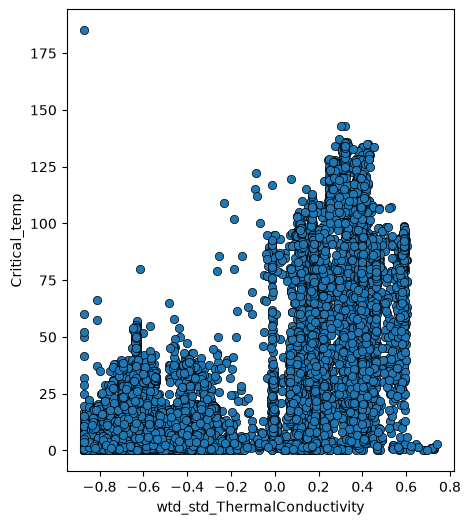

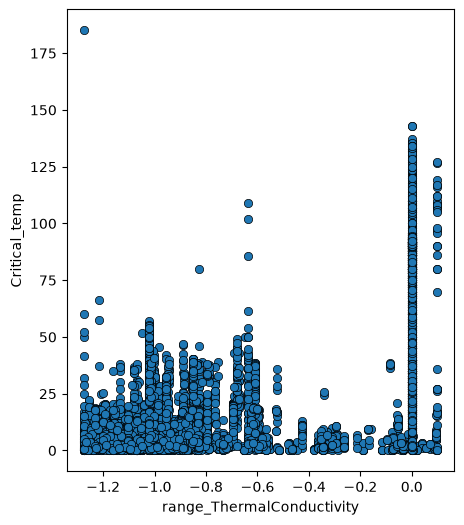

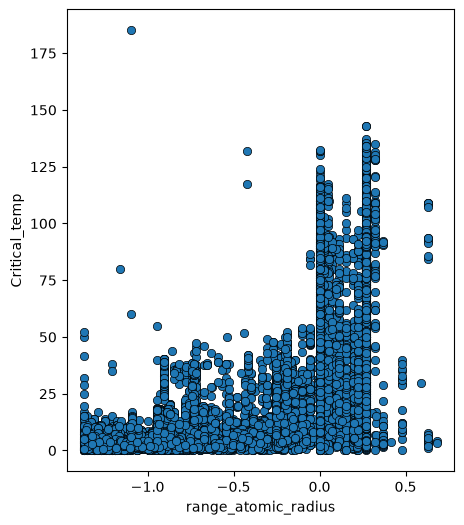

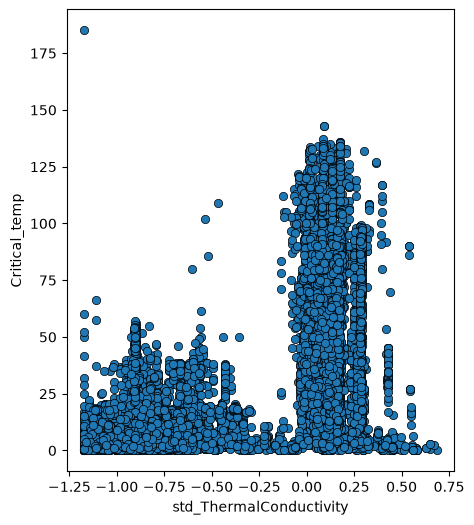

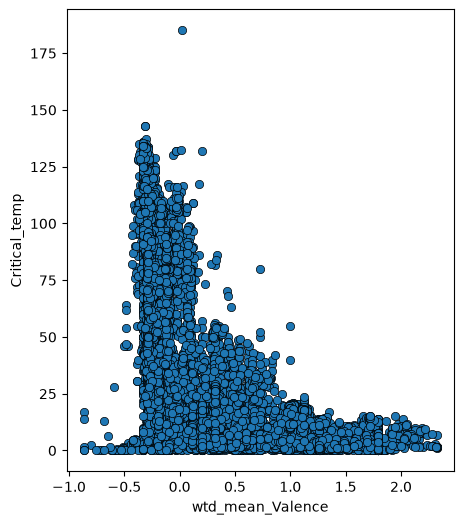

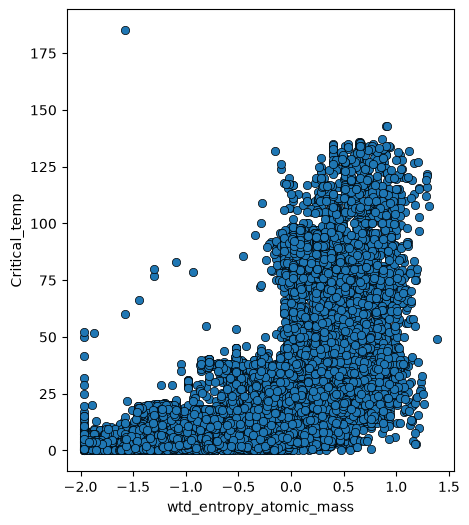

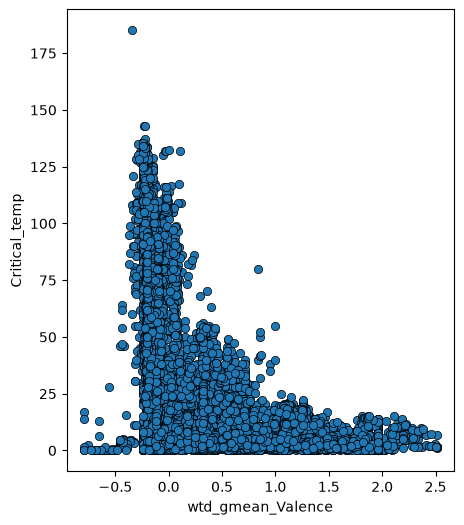

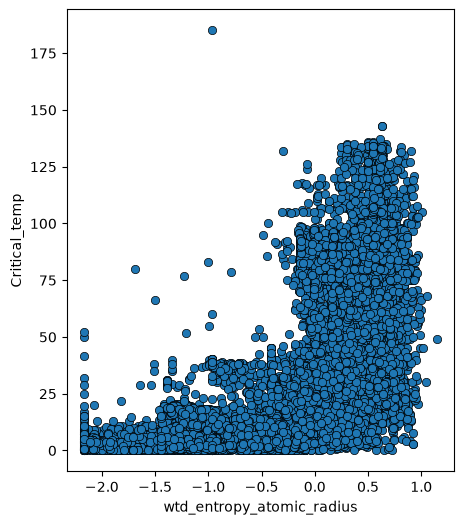

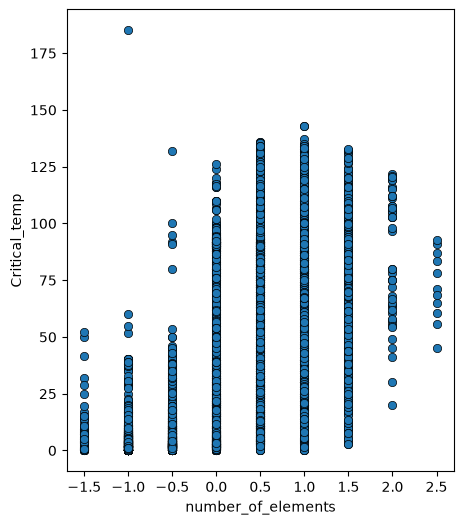

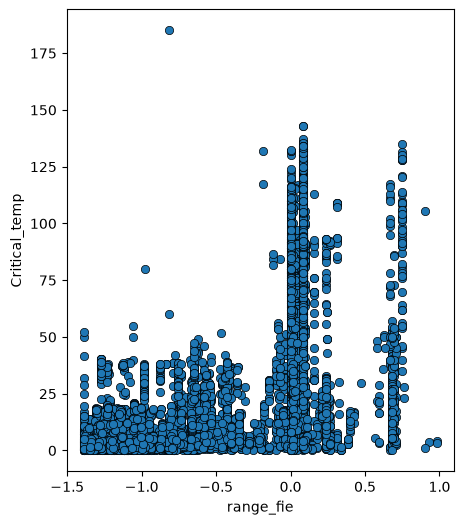

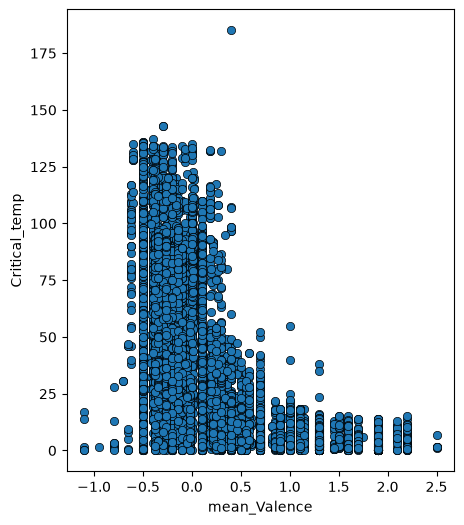

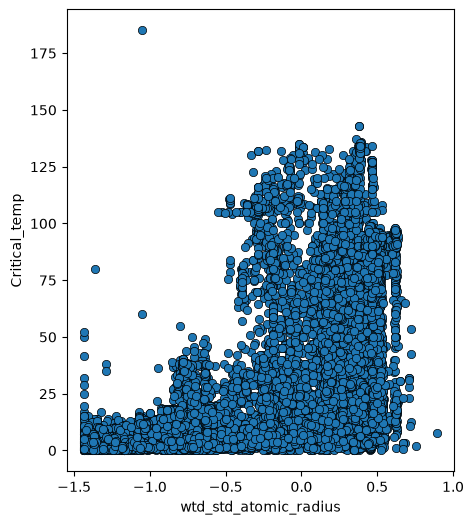

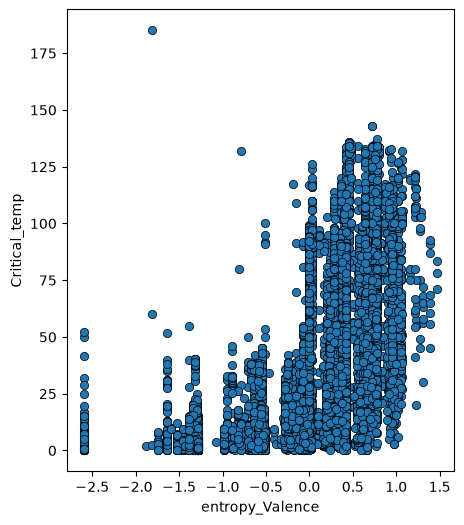

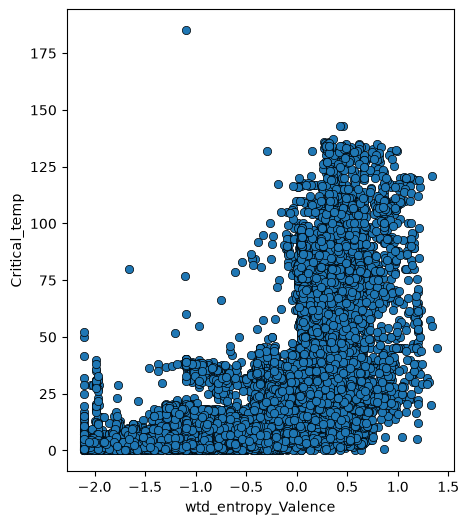

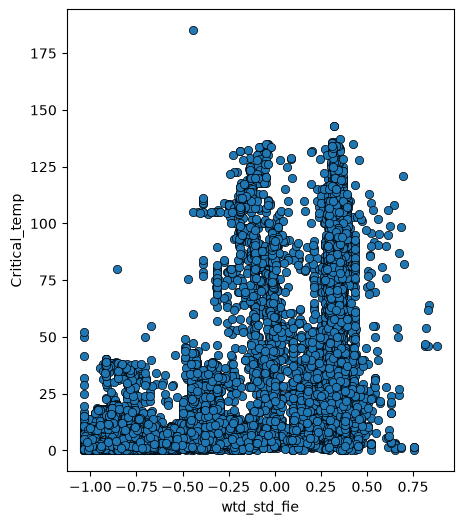

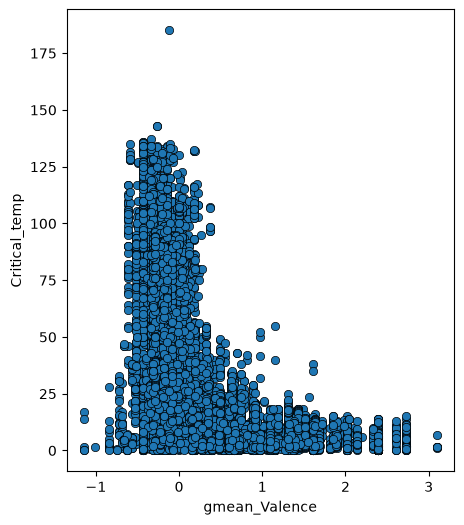

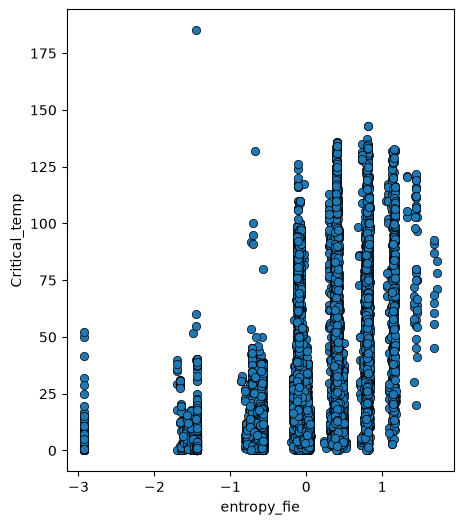

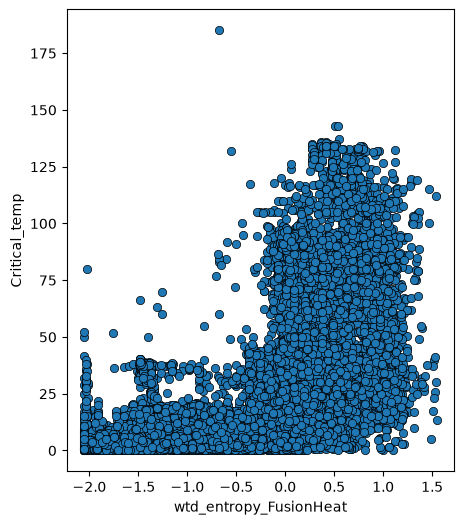

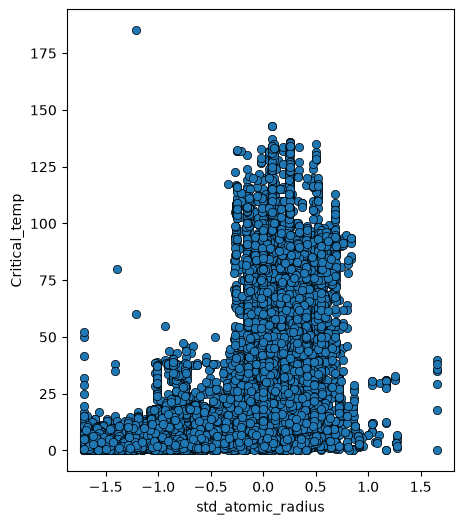

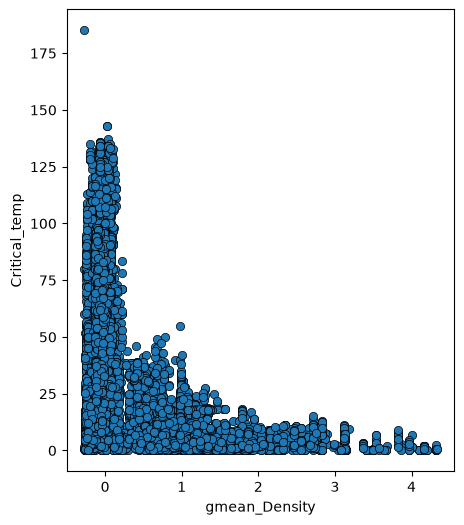

In [37]:
feature_names = x_train_scaled.columns

for i in range(X.shape[1]):
    fig, ax = plt.subplots(figsize=(5,6))

    ax.scatter(
        X[:, i],
        Y,
        marker='o',
        edgecolors='black',
        linewidths=0.5
    )

    ax.set_xlabel(feature_names[i])
    ax.set_ylabel("Critical_temp")

    plt.show()

In [38]:
#compute_cost
def compute_cost(X,y, w, b, lbd):
    cost = 0.0
    reg = 0.0
    m,n = X.shape
    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        cost += (f_wb - y[i])**2

    for i in range(n):
        reg += w[i]**2

    reg_term = (lbd/(2*m)) * reg

    return cost/(2*m) + reg_term



#compute_gradient
def compute_gradient(X, y, w, b, lbd):
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        error = (f_wb - y[i]) 

        dj_db += error

        for j in range(n):
            dj_dw[j] += error * X[i, j] 

    for j in range(n):
        dj_dw[j] += (lbd / m) * w[j]

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

**Gradient_Descent**

In [39]:
def gradient_descent(X_train, y_train, compute_cost, compute_gradient, l_rate, iter, w_i, b_i,lbd):

    J_hist = []
    param_hist = []
    iteration = []
    b = b_i
    w = w_i


    for i in range(iter):
        dj_dw,dj_db = compute_gradient(X_train,y_train, w, b,lbd)

        w = w - (dj_dw * l_rate)
        b = b - (dj_db * l_rate)

       

        if(i%(math.ceil(iter/10)) == 0):
            iteration.append(i)
            J_hist.append(compute_cost(X_train, y_train, w,b, lbd))
            param_hist.append([w,b])
            print(f"iteration: {i} || Cost: {J_hist[-1]}")

            
    return w,b, J_hist, param_hist, iteration





In [40]:


def viewCost(J_hist, iteration, param_hist):
    plt.plot(iteration, J_hist)
    plt.title("Cost Function Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Cost (J)")
    plt.show()




In [15]:
w_i = np.zeros((x_train.shape[1]))
b_i = 0.0
w,b, J_hist, param_hist, iteration = gradient_descent(X,Y,compute_cost, compute_gradient, 0.001, 2000,w_i,b_i, 0.001)


iteration: 0 || Cost: 1188.2456881066269
iteration: 200 || Cost: 865.8021433723486
iteration: 400 || Cost: 678.1918815704156
iteration: 600 || Cost: 559.4572078362326
iteration: 800 || Cost: 481.8928968145024
iteration: 1000 || Cost: 429.70227113423107
iteration: 1200 || Cost: 393.5008732153778
iteration: 1400 || Cost: 367.6198170712168
iteration: 1600 || Cost: 348.5750183957503
iteration: 1800 || Cost: 334.1822095693418


[np.float64(1188.2456881066269), np.float64(865.8021433723486), np.float64(678.1918815704156), np.float64(559.4572078362326), np.float64(481.8928968145024), np.float64(429.70227113423107), np.float64(393.5008732153778), np.float64(367.6198170712168), np.float64(348.5750183957503), np.float64(334.1822095693418)]


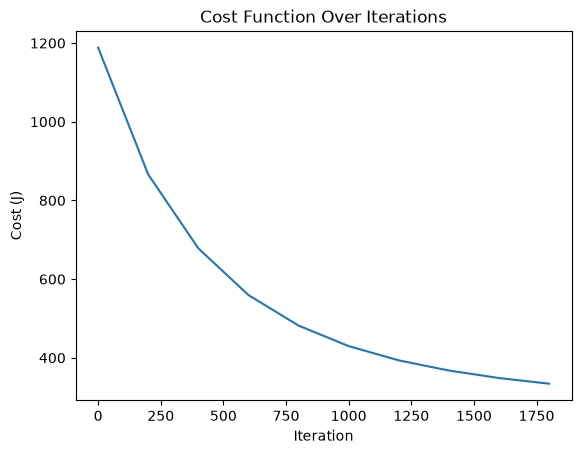

In [16]:
print(J_hist)
viewCost(J_hist, iteration, param_hist)
# print(w.shape)
# print(J_hist.size())


In [17]:
def predict(X,w,b):
    return np.dot(X,w) + b

[36.16584    38.11987762 36.69542788 ... 11.7128477  10.41549681
  6.58935471]


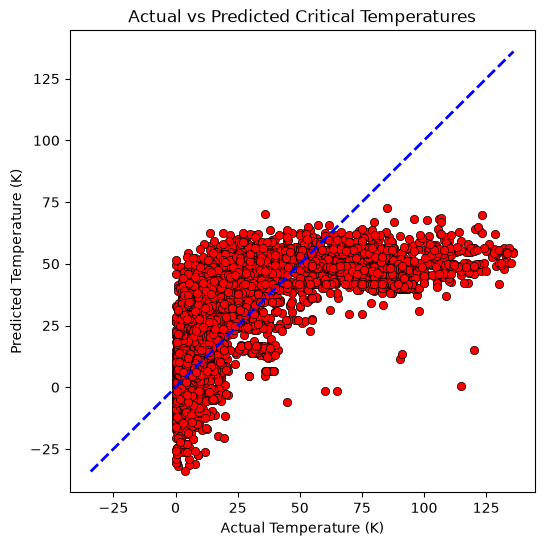

In [18]:
y_pred = predict(X_test, w, b)
print(y_pred)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    color='red',
    edgecolors='black',
    linewidths=0.5
)


min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'b--',
    linewidth=2
)

plt.title("Actual vs Predicted Critical Temperatures")
plt.xlabel("Actual Temperature (K)")
plt.ylabel("Predicted Temperature (K)")


plt.show()

In [19]:
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)

r2 = 1 - (ss_res/ss_tot)

print("R² =", r2)

R² = 0.4618720615431765


In [20]:
train_pred = predict(X, w, b)

train_mse = np.mean((Y - train_pred)**2)
test_mse = np.mean((y_test - y_pred)**2)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 646.1808987959294
Test MSE: 616.8786738783565


## Performing Gradient Descent by squaring the featues

In [57]:
for feature in selected_features:
    x_train[feature + "_sq"] = x_train[feature] ** 2
    x_test[feature + "_sq"] = x_test[feature] ** 2



# Standardize after squaring
X_scaled = (x_train - x_train.mean(axis=0)) / x_train.std(axis=0)
X_test_scaled = (x_test - x_test.mean(axis=0)) / x_test.std(axis=0)


In [ ]:
w_i = np.zeros((X_scaled.shape[1],))
b_i = 0.0

# Convert to numpy arrays on the fly to bypass Pandas indexing
X_numpy = X_scaled.to_numpy() if hasattr(X_scaled, 'to_numpy') else np.asarray(X_scaled)
Y_numpy = Y.to_numpy().flatten() if hasattr(Y, 'to_numpy') else np.asarray(Y).flatten()

# Run gradient descent safely
w, b, J_hist, param_hist, iteration = gradient_descent(
    X_numpy, Y_numpy, compute_cost, compute_gradient, 0.001, 5000, w_i, b_i, 20
)

iteration: 0 || Cost: 1172.0742535131749
iteration: 500 || Cost: 478.508199363971
iteration: 1000 || Cost: 329.00731871738424
iteration: 1500 || Cost: 271.62409316295236
iteration: 2000 || Cost: 248.18998216943308
iteration: 2500 || Cost: 237.66083938251273
iteration: 3000 || Cost: 232.23706436235722
iteration: 3500 || Cost: 228.96961847765897
iteration: 4000 || Cost: 226.71030065297603
iteration: 4500 || Cost: 224.989057681739


[np.float64(1172.0742535131749), np.float64(478.508199363971), np.float64(329.00731871738424), np.float64(271.62409316295236), np.float64(248.18998216943308), np.float64(237.66083938251273), np.float64(232.23706436235722), np.float64(228.96961847765897), np.float64(226.71030065297603), np.float64(224.989057681739)]


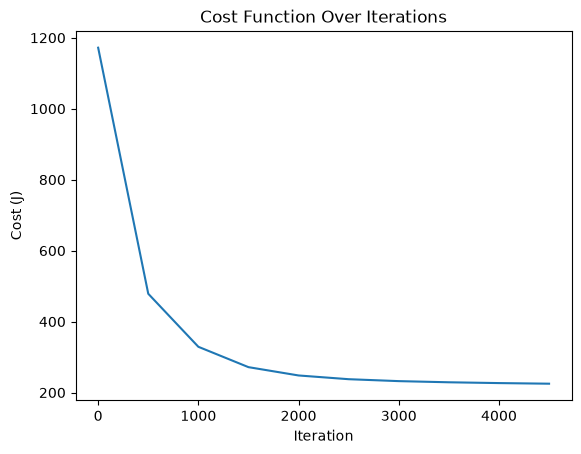

In [55]:
print(J_hist)
viewCost(J_hist, iteration, param_hist)
# print(w.shape)
# print(J_hist.size())


Actual test shape: (5316,)
Predicted shape:   (5316,)


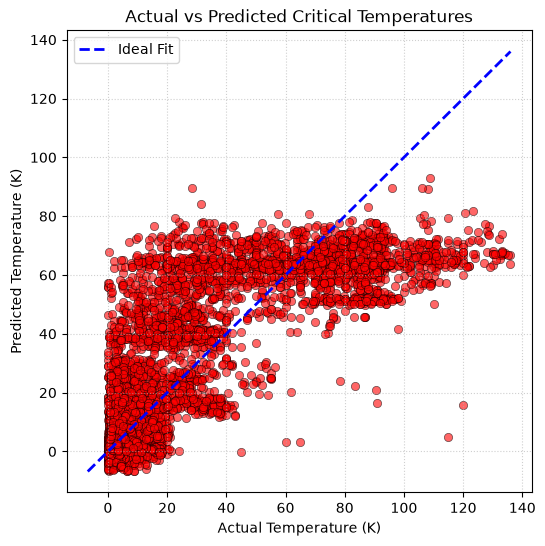

In [64]:
# 1. FIX: Make sure to convert your TEST features here, not X_scaled (training)
# Replace 'X_test_scaled' with the exact name of your scaled testing feature matrix
X_test_numpy = X_test_scaled.to_numpy() if hasattr(X_test_scaled, 'to_numpy') else np.asarray(X_test_scaled)

# 2. Convert and flatten your test targets
Y_test_numpy = y_test.to_numpy().flatten() if hasattr(y_test, 'to_numpy') else np.asarray(y_test).flatten()

# 3. Predict using the corrected test features matrix and flatten it
y_pred = predict(X_test_numpy, w, b).flatten()

# Print shapes to verify they match perfectly now
print("Actual test shape:", Y_test_numpy.shape)
print("Predicted shape:  ", y_pred.shape)

# 4. Plotting
plt.figure(figsize=(6,6))

plt.scatter(
    Y_test_numpy,
    y_pred,
    color='red',
    edgecolors='black',
    linewidths=0.5,
    alpha=0.6
)

# Reference line limits
min_val = min(Y_test_numpy.min(), y_pred.min())
max_val = max(Y_test_numpy.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'b--',
    linewidth=2,
    label='Ideal Fit'
)

plt.title("Actual vs Predicted Critical Temperatures")
plt.xlabel("Actual Temperature (K)")
plt.ylabel("Predicted Temperature (K)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

In [65]:
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)

r2 = 1 - (ss_res/ss_tot)

print("R² =", r2)

R² = 0.6124446047143814


In [67]:
train_pred = predict(X_numpy, w, b)

train_mse = np.mean((Y_numpy - train_pred)**2)
test_mse = np.mean((Y_test_numpy - y_pred)**2)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 446.9105733414282
Test MSE: 444.27103893505915
